# Unzip the data

In [1]:
import zipfile

with zipfile.ZipFile("../data/raw/ml-latest-small.zip", "r") as file:
    file.extractall("../data/raw/")

# Read the dataset files

In [2]:
import pandas as pd

In [3]:
movies = pd.read_csv("../data/raw/ml-latest-small/movies.csv")

movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [3]:
ratings = pd.read_csv("../data/raw/ml-latest-small/ratings.csv")

ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [5]:
tags = pd.read_csv("../data/raw/ml-latest-small/tags.csv")

tags.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


# 1. Dataset Overview

## Number of unique users

In [6]:
ratings["userId"].nunique()

610

## Number of unique movies

In [8]:
ratings["movieId"].nunique()

9724

## Total interactions

We have the Star ratings as interactions in our data

In [18]:
int(ratings["rating"].count())

100836

## Rating scale

In [11]:
ratings["rating"].value_counts()

rating
4.0    26818
3.0    20047
5.0    13211
3.5    13136
4.5     8551
2.0     7551
2.5     5550
1.0     2811
1.5     1791
0.5     1370
Name: count, dtype: int64

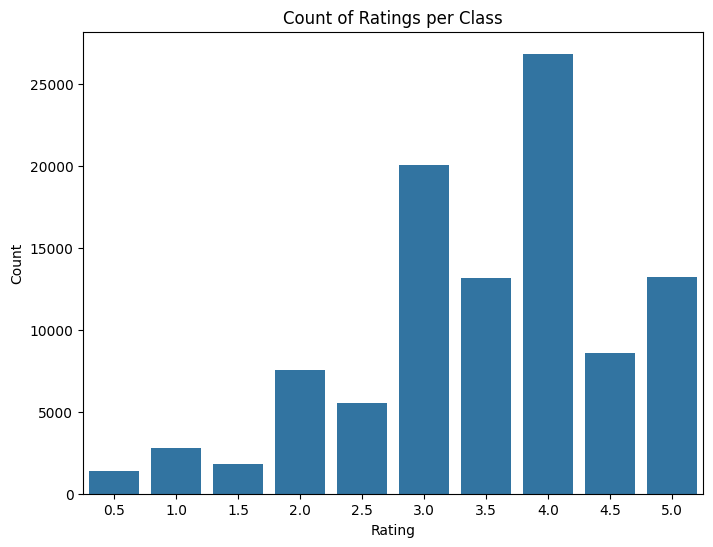

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the count plot
plt.figure(figsize=(8, 6)) # Optional: Adjusts plot size
sns.countplot(x='rating', data=ratings)
plt.title('Count of Ratings per Class')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()


## Average rating

In [19]:
float(ratings["rating"].mean())

3.501556983616962

# 2. Sparsity Analysis

Sparsity refers to the high percentage of missing values in the user-item interaction matrix, where most users have only interacted with a tiny fraction of available items. It occurs when the number of items significantly exceeds user ratings, making it difficult to find similarities, leading to lower recommendation accuracy, poor coverage, and the "cold start" problem.

In [28]:
sparsity = 1 - (ratings["rating"].count())/ (ratings["userId"].nunique() * ratings["rating"].count())

print(f"Sparsity: {sparsity * 100:.2f}%")

Sparsity: 99.84%


# 3. Rating Distribution

A KDE (Kernel Density Estimate) plot is a method for visualizing the distribution of observations in a dataset, similar to a histogram but with a smooth, continuous curve.

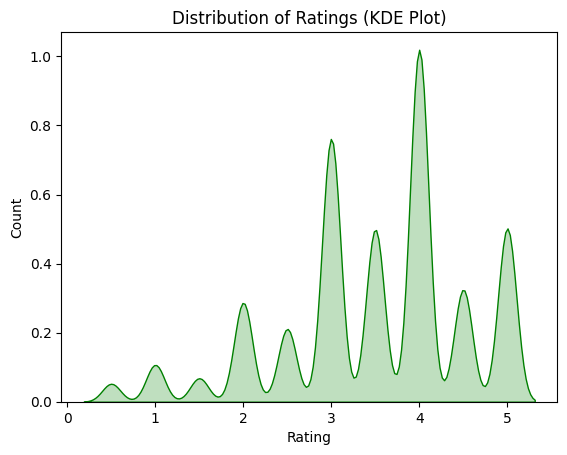

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot a KDE plot
sns.kdeplot(ratings["rating"], fill=True, color='green')
plt.title('Distribution of Ratings (KDE Plot)')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

# 4. User Activity Analysis

## Number of ratings per user

In [24]:
ratings_per_user = ratings.groupby('userId')['rating'].agg(['count'])
ratings_per_user

,count
userId,
1,232
2,29
3,39
4,216
5,44
...,...
606,1115
607,187
608,831


## Average rating given by each user

In [19]:
ratings.groupby("userId")["rating"].agg(["mean"])

,mean
userId,
1,4.366379
2,3.948276
3,2.435897
4,3.555556
5,3.636364
...,...
606,3.657399
607,3.786096
608,3.134176


## Super Users

Super users are users who have an extremely high number of interactions i.e ratings in our case.

Characteristics and impacts of super users include:

- **High Interaction Volume**: While most users might have a few interactions, super users have hundreds or thousands, making their data highly influential in collaborative filtering models.
- **Impact on Data Distribution**: They often create a long-tail distribution in the dataset, where a small percentage of users (the super users) account for a large percentage of the total interactions.
- **Noise and Bias**: In e-commerce, super users can represent "abnormal" traffic (e.g., automated bots or scraping tools), which adds noise to the data, reduces the effectiveness of recommendations, and biases split tests.
- **Handling in Datasets**: To prevent these users from dominating the model and causing over-fitting or recommending the same items to everyone, they are often filtered out or sampled differently during data preprocessing

In [51]:
mean_rating_count = int(ratings_per_user["count"].mean())
print("Mean Rating Count:", mean_rating_count)

# Find super users (counts >= mean)
super_user_idx = ratings_per_user[ratings_per_user["count"] >= mean_rating_count].index

print("Number of super users:", len(super_user_idx))

ratings[ratings["userId"].isin(super_user_idx)]

Mean Rating Count: 165
Number of super users: 159


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
...,...,...,...,...
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352


So there are 159 users in the dataset who have rated more movies than the global average of 165 and they have 72952 interactions combined!